# Comparacion de Datos Categoricos vs. Categoricos

1. La tabla de contingencia
2. Los graficos de barras agrupadas y apiladas

### 1. La tabla de contingencia

In [1]:
import pandas as pd

df = pd.read_csv('../data/data-prestamos.csv')
df

,estado,nivel
0,Totalmente pagada,B
1,Cancelada (impago),C
2,Totalmente pagada,C
3,Totalmente pagada,C
4,Actual,B
...,...,...
450956,Actual,D
450957,Actual,D
450958,Actual,D
450959,Actual,D


In [2]:
tab_conteo = pd.crosstab(df['nivel'], df['estado'])
tab_conteo

estado,Actual,Cancelada (impago),Tarde,Totalmente pagada
nivel,,,,
A,50051,1562,469,20408
B,93852,5302,2056,31160
C,88928,6023,2777,23147
D,53281,5007,2308,13681
E,24639,2842,1374,5949
F,8444,1526,606,2328
G,1990,409,199,643


In [4]:
tab_pctj_all = pd.crosstab(df['nivel'], df['estado'], normalize='all')*100
tab_pctj_all

estado,Actual,Cancelada (impago),Tarde,Totalmente pagada
nivel,,,,
A,11.098742,0.346371,0.104000,4.525447
B,20.811556,1.175711,0.455915,6.909688
C,19.719665,1.335592,0.615796,5.132816
D,11.814991,1.110296,0.511796,3.033743
E,5.463665,0.630210,0.304683,1.319183
F,1.872446,0.338388,0.134380,0.516231
G,0.441280,0.090695,0.044128,0.142584


In [5]:
tab_pctj_nivel = pd.crosstab(df['nivel'], df['estado'], normalize='index')*100
tab_pctj_nivel

estado,Actual,Cancelada (impago),Tarde,Totalmente pagada
nivel,,,,
A,69.045386,2.154780,0.646986,28.152849
B,70.901262,4.005439,1.553222,23.540077
C,73.570217,4.982834,2.297415,19.149535
D,71.732838,6.740983,3.107288,18.418891
E,70.793587,8.165728,3.947822,17.092863
F,65.437074,11.825790,4.696218,18.040918
G,61.400802,12.619562,6.140080,19.839556


In [6]:
tab_pctj_nivel.sum(axis=1)

nivel
A    100.0
B    100.0
C    100.0
D    100.0
E    100.0
F    100.0
G    100.0
dtype: float64

In [7]:
tab_pctj_estado = pd.crosstab(df['nivel'], df['estado'], normalize='columns')*100
tab_pctj_estado

estado,Actual,Cancelada (impago),Tarde,Totalmente pagada
nivel,,,,
A,15.583231,6.889859,4.791092,20.970858
B,29.220543,23.386705,21.003167,32.019401
C,27.687470,26.566980,28.368577,23.785400
D,16.588882,22.085484,23.577485,14.058325
E,7.671280,12.535839,14.036163,6.113075
F,2.629014,6.731066,6.190622,2.392207
G,0.619581,1.804067,2.032894,0.660734


In [8]:
tab_pctj_estado.sum(axis=0)

estado
Actual                100.0
Cancelada (impago)    100.0
Tarde                 100.0
Totalmente pagada     100.0
dtype: float64

### 2. Grafico de barras agrupadas

In [9]:
tab_conteo

estado,Actual,Cancelada (impago),Tarde,Totalmente pagada
nivel,,,,
A,50051,1562,469,20408
B,93852,5302,2056,31160
C,88928,6023,2777,23147
D,53281,5007,2308,13681
E,24639,2842,1374,5949
F,8444,1526,606,2328
G,1990,409,199,643


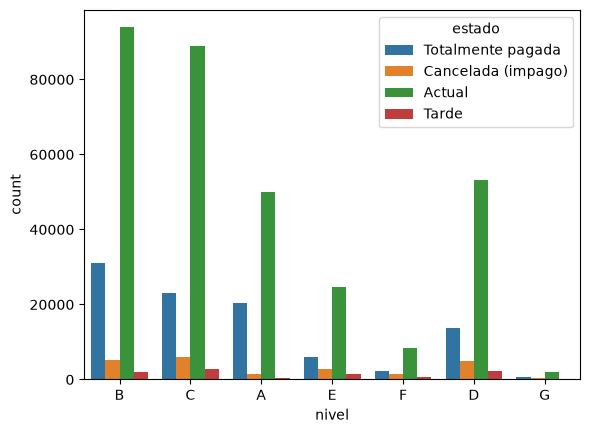

In [11]:
import seaborn as sns

sns.countplot(data=df, x='nivel', hue='estado');

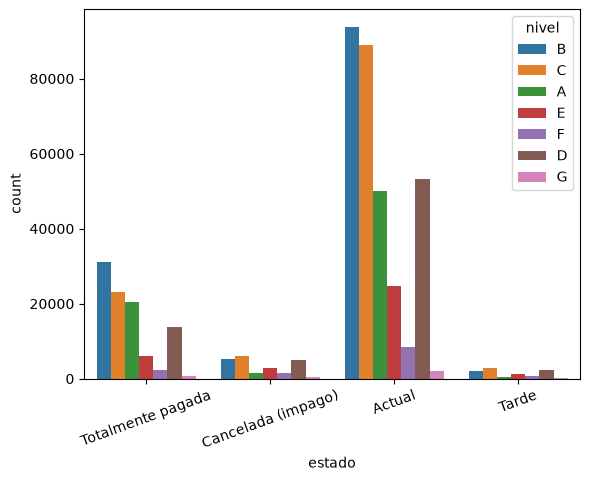

In [15]:
ax = sns.countplot(data=df, x='estado', hue='nivel')
ax.tick_params(axis='x', rotation=20);

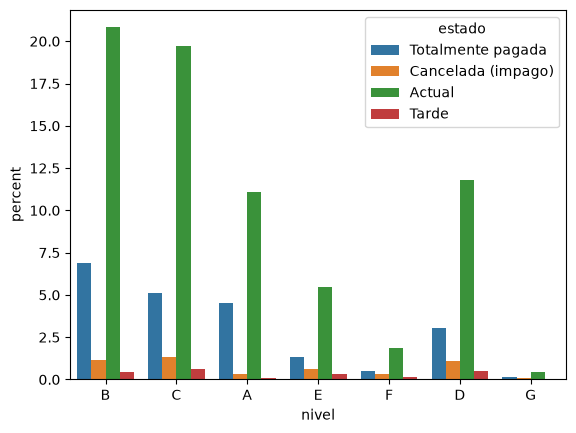

In [17]:
sns.countplot(data=df, x='nivel', hue='estado', stat='percent');

### 3. Grafico de barras apiladas

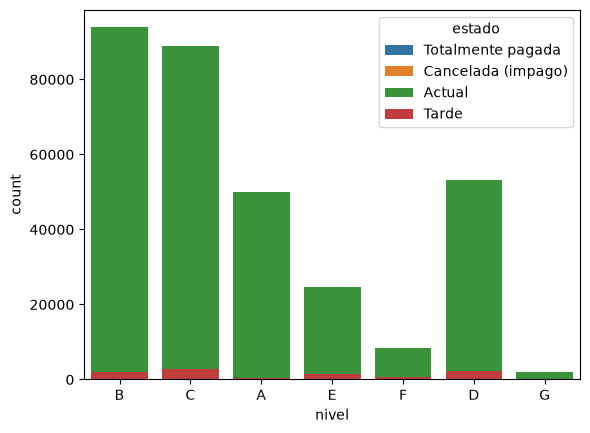

In [18]:
sns.countplot(data=df, x='nivel', hue='estado', dodge=False);

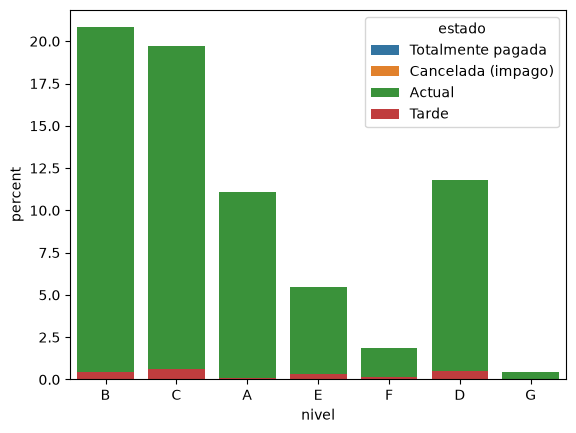

In [19]:
sns.countplot(data=df, x='nivel', hue='estado', dodge=False, stat='percent');

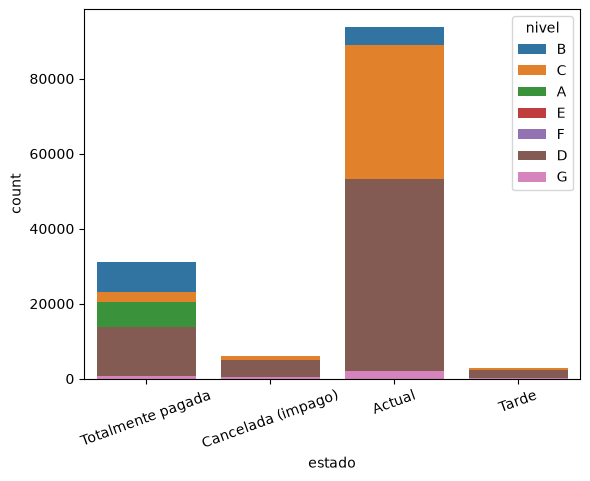

In [20]:
ax = sns.countplot(data=df, x='estado', hue='nivel', dodge=False)
ax.tick_params(axis='x', rotation=20);

# Comparacion de datos categoricos vs numericos

In [22]:
df = pd.read_csv('../data/estadisticas_aerolineas.csv')
df

,pct_retraso_aerol,pct_retraso_aerop,pct_retraso_clima,aerolínea
0,8.153226,1.971774,0.762097,American
1,5.959924,3.706107,1.585878,American
2,7.157270,2.706231,2.026706,American
3,12.100000,11.033333,0.000000,American
4,7.333333,3.365591,1.774194,American
...,...,...,...,...
33463,6.186422,8.798491,1.651940,Southwest
33464,9.522167,3.591133,0.261084,Southwest
33465,9.164179,2.664179,0.343284,Southwest
33466,5.152293,1.964520,0.122817,Southwest


1. ¿Cual es el principal factor culpable del mayor porcentaje de retraso independientemente de la aeroline?
2. ¿Cuales son las aerolineas con mejor (menos porcentaje de retraso) y peor desempeño (mas porcentaje de retraso) ?

In [23]:
df['aerolínea'].unique()

<StringArray>
['American', 'Alaska', 'Jet Blue', 'Delta', 'United', 'Southwest']
Length: 6, dtype: str

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 33468 entries, 0 to 33467
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pct_retraso_aerol  33440 non-null  float64
 1   pct_retraso_aerop  33440 non-null  float64
 2   pct_retraso_clima  33440 non-null  float64
 3   aerolínea          33468 non-null  str    
dtypes: float64(3), str(1)
memory usage: 1.0 MB


In [25]:
df.isna().sum()

pct_retraso_aerol    28
pct_retraso_aerop    28
pct_retraso_clima    28
aerolínea             0
dtype: int64

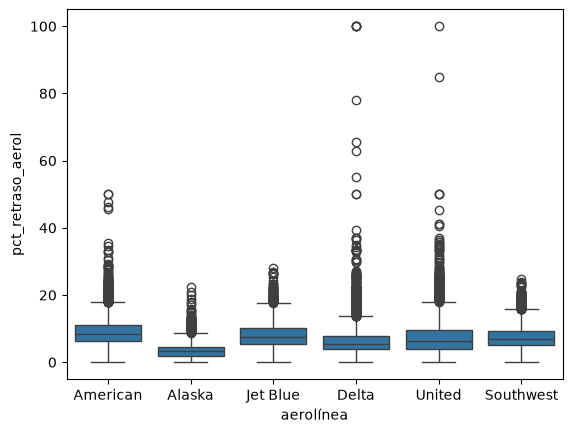

In [27]:
sns.boxplot(data=df, x='aerolínea', y='pct_retraso_aerol');

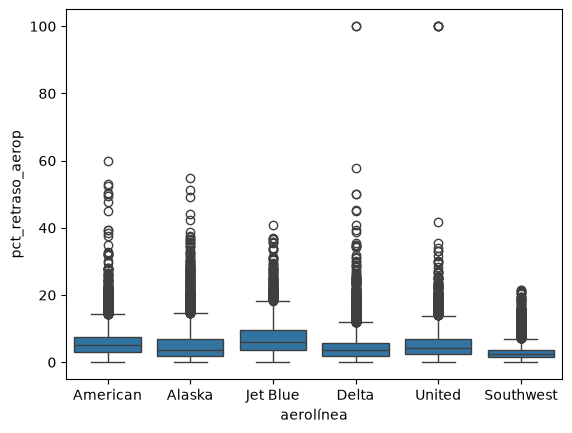

In [28]:
sns.boxplot(data=df, x='aerolínea', y='pct_retraso_aerop');

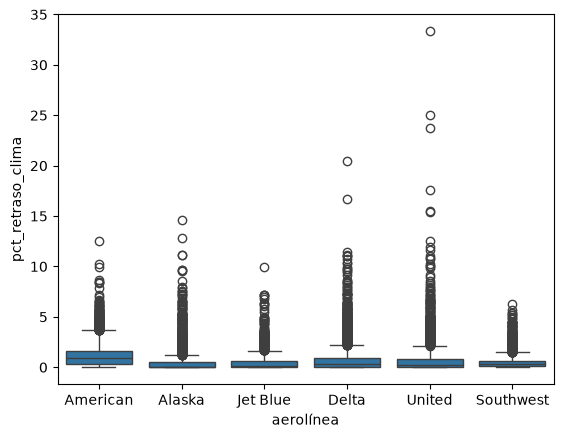

In [29]:
sns.boxplot(data=df, x='aerolínea', y='pct_retraso_clima');

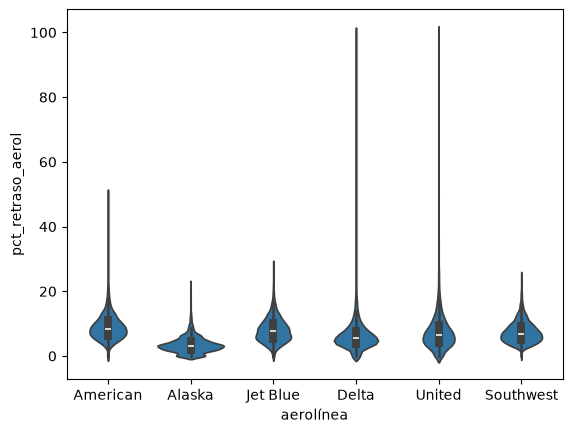

In [30]:
sns.violinplot(data=df, x='aerolínea', y='pct_retraso_aerol');

In [32]:
df.groupby('aerolínea')['pct_retraso_aerol'].median()

aerolínea
Alaska       3.225806
American     8.428571
Delta        5.548387
Jet Blue     7.657895
Southwest    6.960930
United       6.445210
Name: pct_retraso_aerol, dtype: float64

In [33]:
df.groupby('aerolínea')['pct_retraso_aerol'].mean()

aerolínea
Alaska       3.521889
American     9.042180
Delta        6.333460
Jet Blue     8.081843
Southwest    7.521997
United       7.398833
Name: pct_retraso_aerol, dtype: float64

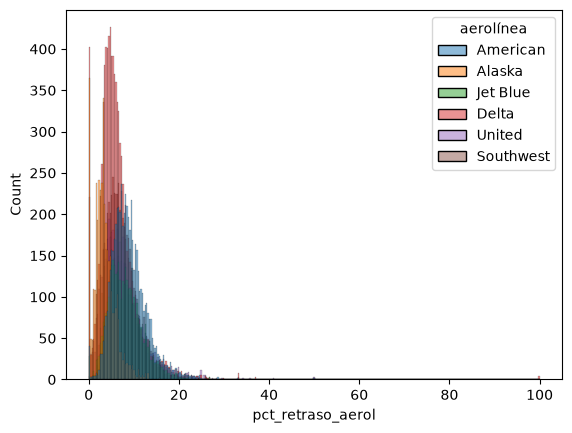

In [38]:
sns.histplot(data=df, x='pct_retraso_aerol', hue='aerolínea');

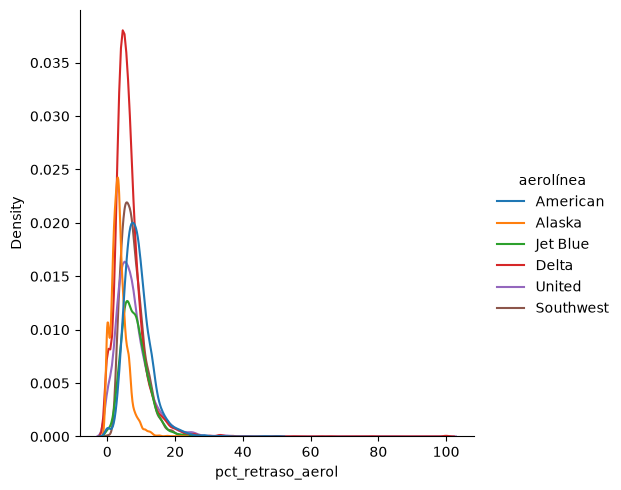

In [40]:
sns.displot(data=df, x='pct_retraso_aerol', hue='aerolínea', kind='kde');